In [42]:
import pandas as pd
import yaml
#import importlib # to refresh functions imported from functions.py file
#import functions # functions.function_name
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns

In [61]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [62]:
df = pd.read_csv(config['output_data']['file'])

### hypothesis: correlation between product category and rating
#### strategy: 
group by category, within each category calculate the mean,std,max,min for price
look for a correlation between mean price and rating
##### caveat: 
sub categories could have major price diff: e.g. laptop vs charging cable

In [73]:
stats_df = df.groupby('sub_cat1').agg(
    mean_price=('actual_price', 'mean'),
    max_price=('actual_price', 'max'),
    min_price=('actual_price', 'min'),
    std_price=('actual_price', 'std'),
    count_price=('actual_price', 'count')
).reset_index()
rating_df = df.groupby('sub_cat1')['rating'].mean().reset_index(name='mean_rating')

# Merge stats and rating DataFrames
final_df = pd.merge(stats_df, rating_df, on='sub_cat1').round(2)
final_df[final_df.count_price >10]

,sub_cat1,mean_price,max_price,min_price,std_price,count_price,mean_rating
1,Computers_Accessories,206659.70,6654444.44,4333.33,471773.79,373,4.15
2,Electronics,1141334.03,15544444.44,19000.00,1787800.43,476,4.07
5,Home_Kitchen,462452.63,8443333.33,8777.78,755744.73,448,4.03
7,OfficeProducts,44132.62,333222.22,5555.56,61420.20,31,4.31


In [91]:
stats_df = df.groupby('sub_cat2').agg(
    mean_price=('actual_price', 'mean'),
    max_price=('actual_price', 'max'),
    min_price=('actual_price', 'min'),
    std_price=('actual_price', 'std'),
    count_price=('actual_price', 'count')
).reset_index()
rating_df = df.groupby(['sub_cat1', 'sub_cat2'])['rating'].mean().reset_index(name='mean_rating')

# Merge stats and rating DataFrames
final_df = pd.merge(stats_df, rating_df, on='sub_cat2').round(2)
final_df[final_df.count_price >10].sort_values(['sub_cat1','count_price'], ascending=[True,False])

,sub_cat2,mean_price,max_price,min_price,std_price,count_price,sub_cat1,mean_rating
1,Accessories_Peripherals,132436.31,611000.00,4333.33,99280.52,305,Computers_Accessories,4.15
22,NetworkingDevices,248981.48,611000.00,38777.78,144836.35,30,Computers_Accessories,4.16
8,ExternalDevices_DataStorage,478117.28,3555555.56,50000.00,809950.25,18,Computers_Accessories,4.32
26,Printers_Inks_Accessories,374656.16,1069444.44,44888.89,348089.17,11,Computers_Accessories,3.96
15,HomeTheater_TV_Video,1959593.07,15544444.44,44333.33,2609435.55,154,Electronics,4.07
20,Mobiles_Accessories,1104829.18,8333222.22,19000.00,1323615.54,147,Electronics,4.13
10,Headphones_Earbuds_Accessories,319368.61,1776666.67,44333.33,297077.70,63,Electronics,3.92
28,WearableTechnology,842034.98,3333222.22,111000.00,501000.25,54,Electronics,3.97
3,Cameras_Photography,288243.06,833333.33,44444.44,237628.79,16,Electronics,4.12
12,HomeAudio,346236.11,1388777.78,66666.67,317320.25,16,Electronics,4.07


C:\Users\clair\AppData\Local\Temp\ipykernel_12452\2878455486.py:86: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=True)
C:\Users\clair\AppData\Local\Temp\ipykernel_12452\2878455486.py:86: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=True)
C:\Users\clair\documents\IRONHACK\week4\project\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\clair\documents\IRONHACK\week4\project\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


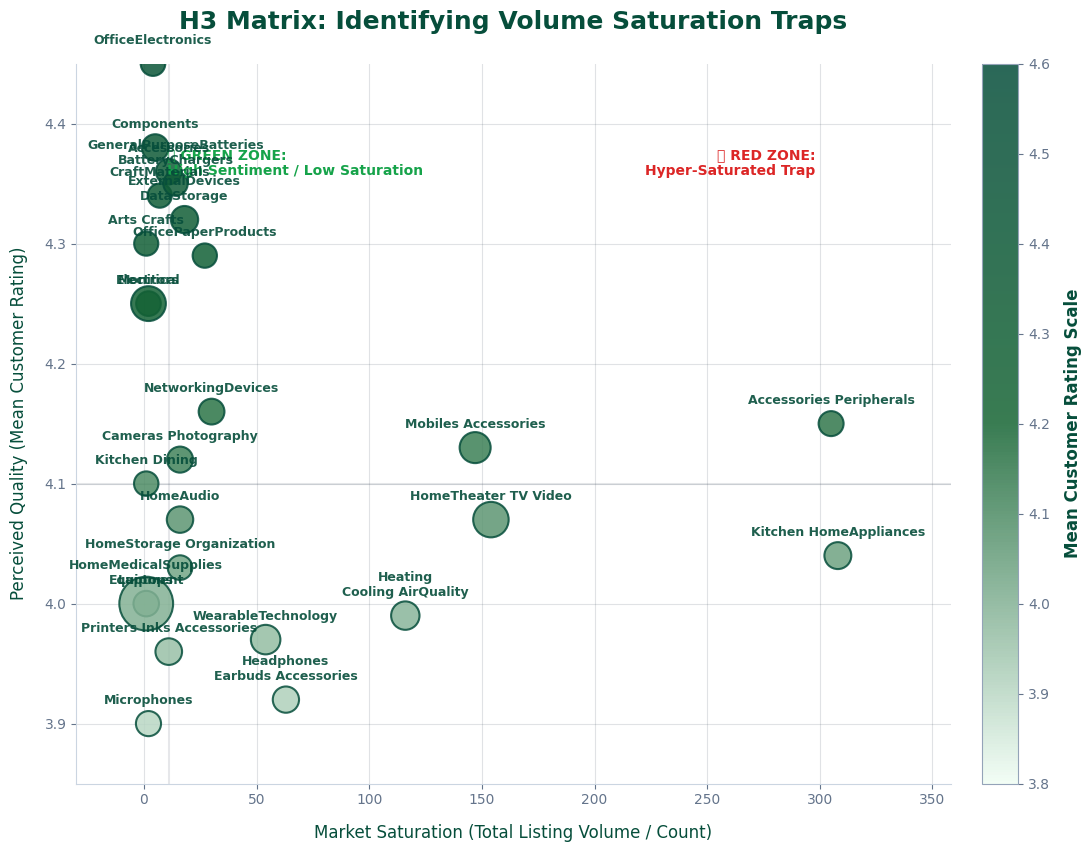

In [126]:
import os
import matplotlib.pyplot as plt

# 1. PRE-CLEAN THE LABELS: Replace underscores and wrap long text onto two lines
def clean_and_wrap(text):
    text = text.replace('_', ' ')
    # If the text is really long, split it dynamically at a space mid-way
    if len(text) > 25:
        words = text.split(' ')
        mid = len(words) // 2
        return '\n'.join([' '.join(words[:mid]), ' '.join(words[mid:])])
    return text

final_df['wrapped_labels'] = final_df['sub_cat2'].astype(str).apply(clean_and_wrap)

# 2. Initialize the plot canvas
fig, ax = plt.subplots(figsize=(13, 9))

# 3. Scale bubble sizes smoothly so they match your layout beautifully
# Base size of 300 + scaling factor relative to price
bubble_sizes = (final_df['mean_price'] / final_df['mean_price'].max()) * 1200 + 300

# 4. Draw the Bubble Chart Matrix
scatter = ax.scatter(
    data=final_df,
    x='count_price',
    y='mean_rating',
    s=bubble_sizes,
    c=final_df['mean_rating'],
    cmap='panda_strategy',                # Pass registered colormap name directly
    alpha=0.85,
    edgecolors=panda_colors['forest_dark'],
    linewidths=1.5,
    zorder=3
)

# 5. Add strategic reference grid lines (Low opacity)
# Sets crosshairs right at the dataset medians to explicitly frame the quadrants
ax.axvline(x=final_df['count_price'].median(), color=panda_colors['slate_line'], linestyle='-', alpha=0.12, zorder=1)
ax.axhline(y=4.10, color=panda_colors['slate_line'], linestyle='-', alpha=0.12, zorder=1)

# 6. Label the Quadrants elegantly
ax.text(10, 4.38, "🟢 GREEN ZONE:\nHigh Sentiment / Low Saturation", color='#16a34a', weight='bold', fontsize=10, va='top')
ax.text(final_df['count_price'].max() - 10, 4.38, "🔴 RED ZONE:\nHyper-Saturated Trap", color='#dc2626', weight='bold', fontsize=10, va='top', ha='right')

# 7. Annotate data points using our new wrapped labels
for i in range(len(final_df)):
    ax.annotate(
        final_df['wrapped_labels'].iloc[i],
        (final_df['count_price'].iloc[i], final_df['mean_rating'].iloc[i]),
        xytext=(0, 12),                  # Push label slightly higher above the bubble center
        textcoords='offset points',
        fontsize=9,
        weight='semibold',
        color=panda_colors['forest_dark'],
        ha='center',                     # Center-align text right over the bubble
        va='bottom',
        alpha=0.9
)

# 8. Title, Axis, and Colorbar styling
ax.set_title("H3 Matrix: Identifying Volume Saturation Traps", pad=25, fontsize=18)
ax.set_xlabel("Market Saturation (Total Listing Volume / Count)", labelpad=12)
ax.set_ylabel("Perceived Quality (Mean Customer Rating)", labelpad=12)

# Set explicit view window boundaries so no text overlaps the borders
ax.set_ylim(3.85, 4.45)
ax.set_xlim(-30, final_df['count_price'].max() + 50)

# Smooth clean layout accents
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cbd5e1')

# Add the brand layout colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.03)
cbar.set_label('Mean Customer Rating Scale', color=panda_colors['forest_dark'], weight='bold', labelpad=10)
cbar.ax.tick_params(colors='#64748b')

# 9. FIX THE CUTOFFS: Apply extra layout breathing room before exporting
plt.subplots_adjust(left=0.08, right=0.90, top=0.90, bottom=0.10)

# Export cleanly
output_path = os.path.join("..", "figures", "h3_saturation_matrix.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=True)

plt.show()

#### Discounting may increase the number of reviews, which can be considered a proxy for sales

In [114]:
df['discount_bin'] = pd.cut(df['discount_percentage'], bins=np.arange(0, 101, 10), right=False)

result = df.groupby('discount_bin').agg(
    count=('rating', 'size'),
    mean_rating=('rating', 'mean')
).reset_index()

clean_labels = [
    '0-10%', '11-20%', '21-30%', '31-40%', '41-50%', 
    '51-60%', '61-70%', '71-80%', '80-90%', '91-100%'
]
print(result)

  discount_bin  count  mean_rating
0      [0, 10)     72     4.211111
1     [10, 20)     90     4.091111
2     [20, 30)    160     4.161250
3     [30, 40)    152     4.105921
4     [40, 50)    211     4.088626
5     [50, 60)    237     4.074684
6     [60, 70)    212     4.067925
7     [70, 80)    127     4.011024
8     [80, 90)     66     4.007576
9    [90, 100)      8     4.062500


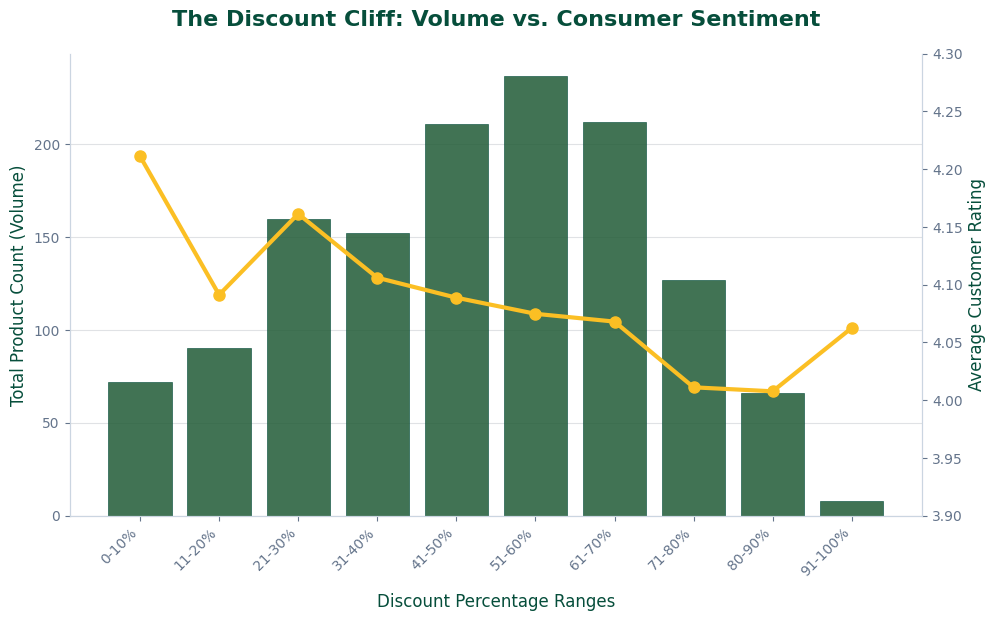

<Figure size 640x480 with 0 Axes>

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the dual-axis figure
fig, ax1 = plt.subplots(figsize=(11, 6))

# Ensure discount bins are explicitly read as discrete categorical strings
result['discount_bin'] = result['discount_bin'].astype(str)

# 2. Primary Axis (ax1): Volume Count Bars
sns.barplot(
    data=result,
    x='discount_bin',
    y='count',
    ax=ax1,
    color=panda_colors['bamboo'],       # Using our core brand green
    alpha=0.85,                         # Slight opacity so it sits softly behind the trend line
    edgecolor=panda_colors['forest_dark'],
    linewidth=0.5
)

# 3. Secondary Axis (ax2): Rating Trend Line
ax2 = ax1.twinx()

ax2.plot(
    result['discount_bin'], 
    result['mean_rating'], 
    color=panda_colors['honey'],        # Highlight color for the strategic insight
    marker='o', 
    markersize=8,
    linestyle='-', 
    linewidth=3,                        # Slightly thicker to establish visual hierarchy
    label='Mean Rating',
    zorder=5                            # Keep line firmly on top of bars
)

# 4. Clean Up Gridlines & Alignments
# CRITICAL FIX: Turn off secondary grids so they don't fight with the primary ones
ax1.grid(True, axis='y', color=panda_colors['slate_line'], linestyle='-', alpha=0.15)
ax2.grid(False)

# Rotate labels on the primary axis safely
ax1.set_xticks(range(len(clean_labels)))
ax1.set_xticklabels(clean_labels, rotation=45, ha='right')
# ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# 5. Semantic Labeling & Coloring
ax1.set_title("The Discount Cliff: Volume vs. Consumer Sentiment", pad=20)
ax1.set_xlabel("Discount Percentage Ranges", labelpad=10)
ax1.set_ylabel("Total Product Count (Volume)", color=panda_colors['forest_dark'])
ax2.set_ylabel("Average Customer Rating", color=panda_colors['forest_dark'])

# Soften the spine colors to match the layout
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['right'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')



# Set specific rating limits so the "Cliff" drop-off looks dramatic and clear
ax2.set_ylim(3.9, 4.3)

# fig.tight_layout()
plt.show()

import os

# Create the cross-platform relative path
output_path = os.path.join("..", "figures", "discount_rating.png")

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

In [122]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 1. Define the PandaMonium Brand Palette
panda_colors = {
    'forest_dark': '#064e3b',    # Deepest green
    'bamboo': '#166534',         # Corporate green
    'honey': '#fbbf24',          # Highlight gold
    'slate_line': '#334155',     # Dark slate for gridlines
    'mint_bg': '#f0fdf4'         # Soft background
}

# 2. Create the Custom Colormap
panda_map = mcolors.LinearSegmentedColormap.from_list(
    'panda_strategy', [panda_colors['mint_bg'], panda_colors['bamboo'], panda_colors['forest_dark']]
)
plt.colormaps.register(cmap=panda_map)

# 3. Refined Global Styling (Fixing the Gridlines)
plt.rcParams.update({
    # Font & Figure
    'font.family': 'sans-serif',
    'figure.facecolor': 'white',
    
    # Axes & Edge styling
    'axes.facecolor': 'white',
    'axes.edgecolor': '#94a3b8',
    'axes.linewidth': 0.8,
    'axes.labelcolor': panda_colors['forest_dark'],
    'axes.titlecolor': panda_colors['forest_dark'],
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    
    # GRIDLINE FIXES: Solid, Transparent, and Behind Data
    'axes.grid': True,
    'axes.axisbelow': True,               # Ensures grid stays behind bars/lines
    'grid.color': panda_colors['slate_line'], # Non-white color
    'grid.linestyle': '-',                # Solid lines
    'grid.alpha': 0.15,                   # High transparency (Fairly transparent)
    'grid.linewidth': 0.8,
    
    # Ticks
    'xtick.color': '#64748b',
    'ytick.color': '#64748b',
    'xtick.direction': 'out',
    'ytick.direction': 'out'
})

print("🐼 PandaMonium Visual Style Updated: Solid transparent gridlines active.")

ValueError: A colormap named "panda_strategy" is already registered.